<a href="https://colab.research.google.com/github/marianaolmedo/Investigacion-de-Operaciones/blob/main/inventario_descuento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inventario con descuento

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

## Ejemplo

LubeCar se especializa en cambios rápidos de aceite para motor de automóvil. El servicio
compra aceite para motor a granel, a $\$3$ por galón. Si LubeCar compra más de 100 galones,
obtiene un descuento de $\$2.50$ por galón. En el servicio se atienden unos 150 autos diarios, y
cada cambio de aceite requiere de 1.25 galones. LubeCar guarda el aceite a granel con un costo
de $\$0.02$ por galón y por día. También, el costo de colocar un pedido de aceite a granel es
de $\$20$. Hay un tiempo de 2 días para la entrega. Determine la política óptima de inventario.

In [3]:
# Definimos los simbolos y funciones
c1, c2, d, h, K, L, Q, Qop, t1=sp.symbols("c1, c2, d, h, K, L, Q, Qop, t1")
T=sp.Function("T")
Qo=sp.Function("Qo")

In [4]:
c1=3
c2=2.5
d=187.5
h=0.02
K=20
L=2
q=1000
#Qop=612.3724

Paso 1. Calcular Q óptimo

In [5]:
def Qop(K,d,h):
    return np.sqrt((2*K*d)/h)

In [6]:
Qo=Qop(K,d,h)

In [7]:
Qo

np.float64(612.3724356957945)

Paso 2. Determinar la zona en que se encuentra q

In [8]:
def T(Q):
    if Q <= q:
        f=c1*d+K*d/Q+h*Q/2
    else:
        f=c2*d+K*d/Q+h*Q/2
    return f

In [9]:
eq=sp.Eq(Q**2 + (2/h)*(c2*d-T(Qo))*Q+2*K*d/h,0)

In [10]:
eq

Eq(Q**2 - 10599.7448713916*Q + 375000.0, 0)

In [11]:
sol=sp.solve(eq,Q)

In [12]:
sol

[35.4970848447485, 10564.2477865469]

In [13]:
s=sol[1] #Aquí debemos seleccionar la solución que sea mayor que q

In [14]:
s

10564.2477865469

Como $Qop=612 < q=1000 < Q = 10564$, q está en la zona II. Por tanto:

Qoo = q

**Ejercicio 1:** Escriba una función que calcula la Q óptima. Es decir, que resuelva de manera interna la ecuación cuadrática y seleccione la solución correcta e indique en qué región está.

In [15]:
def Q_optima(c1, c2, d, h, K, q):

    # Paso 1: Calcular Q óptimo
    Q_eoq = np.sqrt((2*K*d)/h)

    # Paso 2: Determinar la zona en que se encuentra q
    def T(Q):
        if Q <= q:
            return c1*d + K*d/Q + h*Q/2
        else:
            return c2*d + K*d/Q + h*Q/2

    # Paso 3: Resolver la ecuación cuadrática
    Q = sp.Symbol('Q')
    eq = sp.Eq(Q**2 + (2/h)*(c2*d - T(Q_eoq))*Q + (2*K*d)/h, 0)
    sol_f = sp.solve(eq, Q)

    Q_cuad = max([float(s) for s in sol_f if s > 0])

    # Paso 4: determinar región
    if Q_eoq < q and Q_cuad < q:
        region = "Región I"
        Q_final = Q_eoq

    elif Q_eoq < q < Q_cuad:
        region = "Región II"
        Q_final = q

    else:
        region = "Región III"
        Q_final = Q_eoq

    return Q_eoq, Q_cuad, Q_final, region

# Paso5: Imprimir resultados
Q_eoq, Q_cuad, Q_final, region = Q_optima(3, 2.5, 187.5, 0.02, 20, 1000)

print(f"Como Qop = {Q_eoq:.0f} < q = 1000 < Q = {Q_cuad:.0f}, q está en la {region}.")
print(f"Por tanto: Qoo = {Q_final}")

Como Qop = 612 < q = 1000 < Q = 10564, q está en la Región II.
Por tanto: Qoo = 1000


Para calcular el tiempo de retraso efectivo

In [16]:
t1=Qo/d
np.floor(L/t1)

np.float64(0.0)

Por tanto la política del inventario debe ser:

In [17]:
print("Pedir", q, "cuando el inventario caiga a:", L*d)

Pedir 1000 cuando el inventario caiga a: 375.0


**Ejercicio 2:** Escribir una función que reciba los datos del problema y devuelva la política óptima del inventario.

In [22]:
def Q_optima(c1, c2, d, h, K, q, L):

    # Paso 1: Calcular Q óptimo
    Q_eoq = np.sqrt((2*K*d)/h)

    # Paso 2: Determinar la zona en que se encuentra q
    def T(Q):
        if Q <= q:
            return c1*d + K*d/Q + h*Q/2
        else:
            return c2*d + K*d/Q + h*Q/2

    # Paso 3: Resolver la ecuación cuadrática
    Q = sp.Symbol('Q')
    eq = sp.Eq(Q**2 + (2/h)*(c2*d - T(Q_eoq))*Q + (2*K*d)/h, 0)
    sol_f = sp.solve(eq, Q)

    Q_cuad = max([float(s) for s in sol_f if s > 0])

    # Paso 4: determinar región
    if Q_eoq < q and Q_cuad < q:
        region = "Región I"
        Q_final = Q_eoq

    elif Q_eoq < q < Q_cuad:
        region = "Región II"
        Q_final = q

    else:
        region = "Región III"
        Q_final = Q_eoq


    # Paso 5:
    t_ast = Q_eoq / d
    n = int(L / t_ast)

    # Paso 6:
    Le = L - (n * t_ast)

    # Paso 7:
    Led = Le * d

    return {
        "Q_eoq": Q_eoq,
        "Q_cuadratica": Q_cuad,
        "Q_optima": Q_final,
        "Region": region,
        "Led": Led,
        "t_ast": t_ast,
        "n": n
    }


# Paso 8: Ingresar Datos
c1 = 3
c2 = 2.5
d = 187.5
h = 0.02
K = 20
L = 2
q = 1000

# Paso 9: Llamar función
res = Q_optima(c1, c2, d, h, K, q, L)

# Paso 10: Imprimir resultados
print(f"Qop = {res['Q_eoq']:.3f}")
print(f"Q = {res['Q_cuadratica']:.3f}")
print(f"Como Qop = {res['Q_eoq']:.3f} < q = {q} < Q = {res['Q_cuadratica']:.3f}, estamos en {res['Region']}")
print(f"Por tanto, Qoo = {res['Q_optima']}")
print(f"t*: {res['t_ast']}")
print(f"\nPedir {res['Q_optima']} galones cuando el inventario caiga a: {res['Led']} galones")


Qop = 612.372
Q = 10564.248
Como Qop = 612.372 < q = 1000 < Q = 10564.248, estamos en Región II
Por tanto, Qoo = 1000
t*: 3.2659863237109037

Pedir 1000 galones cuando el inventario caiga a: 375.0 galones


Para graficar

In [23]:
def T(Q, c1, c2, h, K, d, q):
    Q = np.array(Q)

    c = np.where(Q <= q, c1, c2)   # opciones

    return c*d + (K*d)/Q + (h*Q)/2

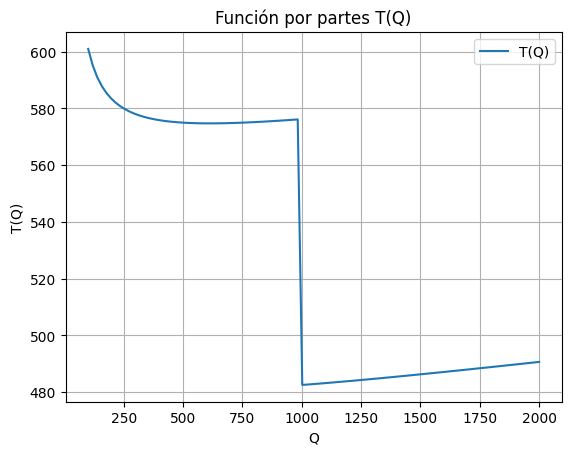

In [24]:
Q_vals = np.linspace(100, 2000, 100)

T_vals = T(Q_vals, c1, c2, h, K, d, q)

plt.plot(Q_vals, T_vals, label="T(Q)")
#plt.axvline(q, color='red', linestyle='--', label="q")  # marca el punto de quiebre

plt.xlabel("Q")
plt.ylabel("T(Q)")
plt.title("Función por partes T(Q)")
plt.legend()
plt.grid(True)
plt.show()

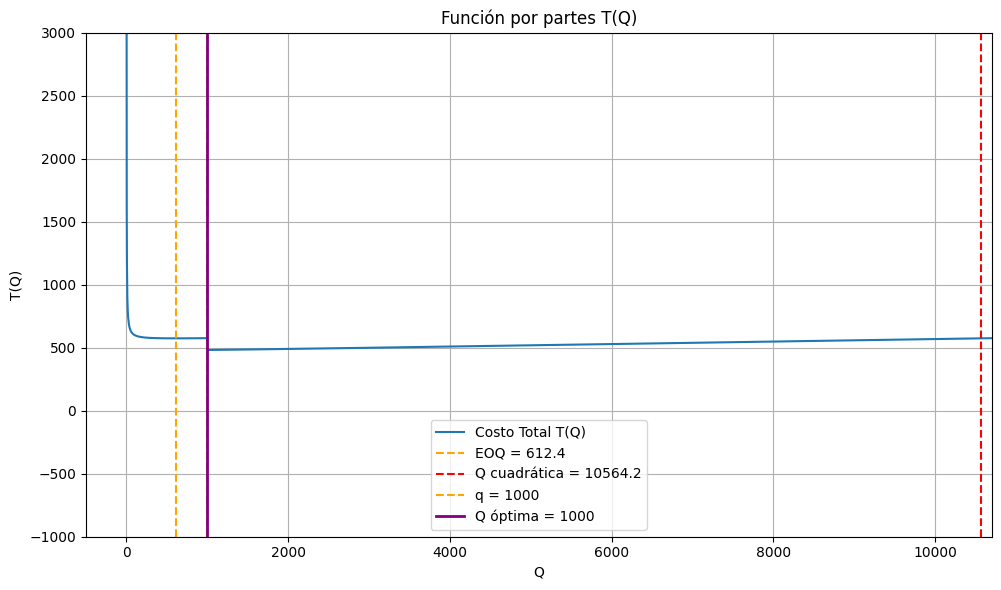

In [25]:
def grafica(c1, c2, d, h, K, q, res):
    Q_vals = np.linspace(1, max(2*q, res['Q_cuadratica']*1.2), 5000)

    def T(Q):
        if Q <= q:
            return c1*d + K*d/Q + h*Q/2
        else:
            return c2*d + K*d/Q + h*Q/2

    T_vec = np.vectorize(T)(Q_vals)
    plt.figure(figsize=(10, 6))

    plt.plot(Q_vals, T_vec, label="Costo Total T(Q)")

    plt.axvline(res['Q_eoq'], color='orange', linestyle='--', label=f"EOQ = {res['Q_eoq']:.1f}")
    plt.axvline(res['Q_cuadratica'], color='red', linestyle='--', label=f"Q cuadrática = {res['Q_cuadratica']:.1f}")
    plt.axvline(q, color='orange', linestyle='--', label=f"q = {q}")
    plt.axvline(res['Q_optima'], color='purple', linestyle='-', linewidth=2, label=f"Q óptima = {res['Q_optima']}")

    plt.xlabel("Q")
    plt.ylabel("T(Q)")
    plt.title("Función por partes T(Q)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.xlim(-500, 10700)
    plt.ylim(-1000, 3000)
    plt.show()


res = Q_optima(c1, c2, d, h, K, q, L)
grafica(c1, c2, d, h, K, q, res)
